# HoVer Train v1.1 Basic EDA

원본 데이터 `data/raw/hover/hover_train_release_v1.1.json` EDA

핵심 질문:
- claim의 개수는?
- claim label의 분포는 어떠한가?
- num_hops의 분포는 어떠한가?
- claim을 입증하기 위한 supporting facts 개수는?

In [1]:
from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_colwidth', 120)

DATA_PATH = Path('../data/raw/hover/hover_train_release_v1.1.json')

with DATA_PATH.open('r', encoding='utf-8') as f:
    raw = json.load(f)

print(f'Total claims: {len(raw):,}')
print(f'Sample keys: {list(raw[0].keys())}')

Total claims: 18,171
Sample keys: ['uid', 'claim', 'supporting_facts', 'label', 'num_hops', 'hpqa_id']


In [2]:
# Hover 데이터 원본 column 파악
rows = []
all_doc_titles = []

for ex in raw:
    sf = ex['supporting_facts']
    doc_titles = [x[0] for x in sf]
    unique_docs = sorted(set(doc_titles))

    rows.append({
        'uid': ex['uid'],
        'claim': ex['claim'],
        'label': ex['label'],
        'num_hops': ex['num_hops'],
        'num_supporting_facts': len(sf),
        'num_unique_docs': len(unique_docs),
        'claim_len_words': len(ex['claim'].split()),
    })

    all_doc_titles.extend(doc_titles)

df = pd.DataFrame(rows)
df.head()

,uid,claim,label,num_hops,num_supporting_facts,num_unique_docs,claim_len_words
0,330ca632-e83f-4011-b11b-0d0158145036,Skagen Painter Peder Severin Krøyer favored naturalism along with Theodor Esbern Philipsen and the artist Ossian Elg...,SUPPORTED,3,4,3,23
1,ca7db8e1-799a-4498-b31b-b1a430b5874e,Skagen Painter Peder Severin Krøyer favored naturalism along with Theodor Esbern Philipsen and the artist Ossian Elg...,SUPPORTED,3,4,3,21
2,2e9cf58a-40e1-47ee-aaa8-3b84ebe94cd0,Skagen Painter Peder Severin Krøyer favored naturalism along with Theodor Esbern Philipsen and the muralist Ossian E...,NOT_SUPPORTED,3,4,3,21
3,f2f4b69d-d833-4f6d-a630-f156a2559af6,"Skagen Painter, who painted the 1893 painting Roses, favored naturalism. Theodor Esbern Philipsen and the artist tha...",NOT_SUPPORTED,4,5,4,28
4,824c8ffa-da36-45ea-9f68-0342e3893a63,Skagen Painter Peder Severin Krøyer favored naturalism along with Norderhov and the artist Ossian Elgström studied w...,NOT_SUPPORTED,3,4,3,19


## 1) Claim 개수

In [3]:
total_claims = len(df)
print(f'? claim ?: {total_claims:,}')

? claim ?: 18,171


## 2) Label 분포

In [4]:
label_counts = df['label'].value_counts().sort_index()
label_ratio = (label_counts / len(df) * 100).round(2)
label_summary = pd.DataFrame({'count': label_counts, 'ratio(%)': label_ratio})
label_summary

,count,ratio(%)
label,,
NOT_SUPPORTED,7148,39.34
SUPPORTED,11023,60.66


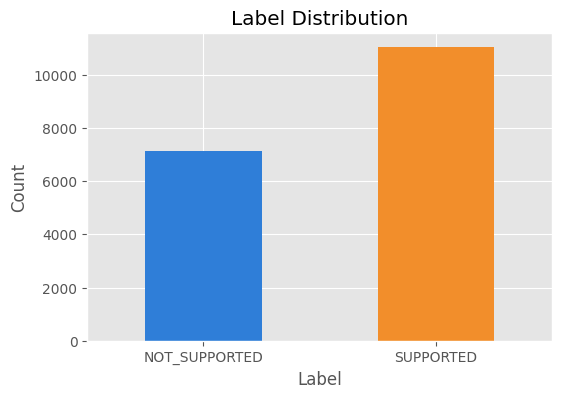

In [5]:
ax = label_counts.plot(kind='bar', figsize=(6,4), color=['#2f7ed8', '#f28e2b'])
ax.set_title('Label Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 3) num_hops 분포

In [6]:
hop_counts = df['num_hops'].value_counts().sort_index()
hop_ratio = (hop_counts / len(df) * 100).round(2)
hop_summary = pd.DataFrame({'count': hop_counts, 'ratio(%)': hop_ratio})
hop_summary

,count,ratio(%)
num_hops,,
2,9052,49.82
3,6084,33.48
4,3035,16.70


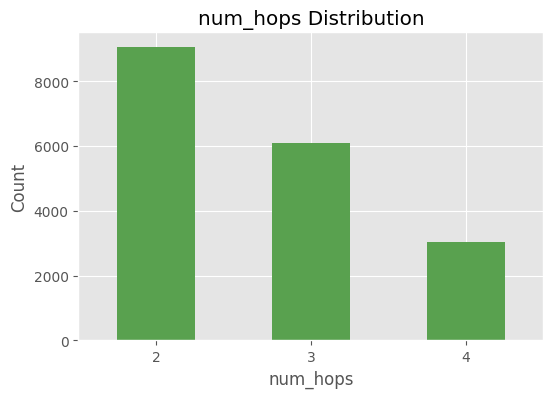

In [7]:
ax = hop_counts.plot(kind='bar', figsize=(6,4), color='#59a14f')
ax.set_title('num_hops Distribution')
ax.set_xlabel('num_hops')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 4) Claim 입증에 필요한 doc 개수

In [16]:
avg_docs = df['num_unique_docs'].mean()
print(f'claim 입증에 필요한 doc 개수 평균: {avg_docs:.3f}')
display(df['num_unique_docs'].value_counts().sort_index().to_frame('count'))

claim 입증에 필요한 doc 개수 평균: 2.669


,count
num_unique_docs,
2,9052
3,6084
4,3035


## EDA A) Supporting Facts 개수

In [9]:
sf_desc = df['num_supporting_facts'].describe().to_frame('num_supporting_facts')
display(sf_desc)
display(df['num_supporting_facts'].value_counts().sort_index().to_frame('count').head(15))

,num_supporting_facts
count,18171.000000
mean,3.071708
std,1.032748
min,2.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,14.000000


,count
num_supporting_facts,
2,6153
3,6445
4,4216
5,1045
6,211
7,57
8,22
9,11
12,2


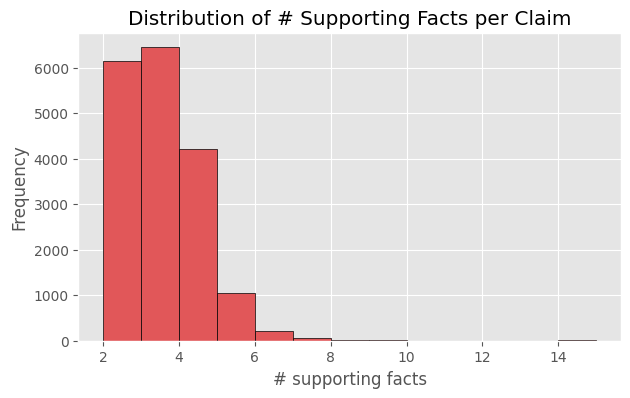

In [10]:
ax = df['num_supporting_facts'].plot(kind='hist', bins=range(2,16), figsize=(7,4), color='#e15759', edgecolor='black')
ax.set_title('Distribution of # Supporting Facts per Claim')
ax.set_xlabel('# supporting facts')
plt.show()

## EDA B) Claim 의 단어 개수 분포

,claim_len_words
count,18171.000000
mean,22.786748
std,9.549848
min,5.000000
25%,16.000000
50%,21.000000
75%,28.000000
max,99.000000


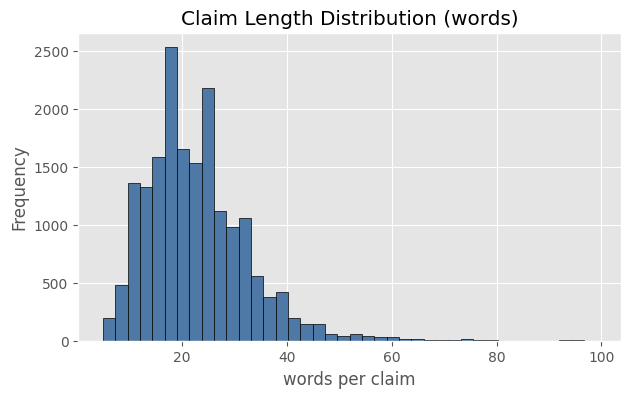

In [11]:
claim_len_desc = df['claim_len_words'].describe().to_frame('claim_len_words')
display(claim_len_desc)
ax = df['claim_len_words'].plot(kind='hist', bins=40, figsize=(7,4), color='#4e79a7', edgecolor='black')
ax.set_title('Claim Length Distribution (words)')
ax.set_xlabel('words per claim')
plt.show()

## EDA C) Label x num_hops 분포

In [12]:
cross = pd.crosstab(df['label'], df['num_hops'])
cross_ratio = (cross.div(cross.sum(axis=1), axis=0) * 100).round(2)
print('Count:')
display(cross)
print('Row-wise ratio(%):')
display(cross_ratio)

Count:


num_hops,2,3,4
label,,,
NOT_SUPPORTED,2556,2813,1779
SUPPORTED,6496,3271,1256


Row-wise ratio(%):


num_hops,2,3,4
label,,,
NOT_SUPPORTED,35.76,39.35,24.89
SUPPORTED,58.93,29.67,11.39


## EDA D) Evidence로 쓰인 문서 Top-20

In [13]:
doc_counter = Counter(all_doc_titles)
top_docs = pd.DataFrame(doc_counter.most_common(20), columns=['doc_title', 'supporting_fact_count'])
top_docs

,doc_title,supporting_fact_count
0,Yukio Mishima,99
1,The Lone Ranger (2013 film),60
2,The Scarlet Letter (1995 film),46
3,Lester James Peries,42
4,Death of Osama bin Laden,39
5,SEAL Team Six,39
6,Gatwick Airport,38
7,Jimmy Butler (basketball),38
8,Kazuo Ishiguro,37
9,Rudolph the Red-Nosed Reindeer (TV special),36


## Summary

In [15]:
summary = {
    'total_claims': int(len(df)),
    'label_distribution': df['label'].value_counts().to_dict(),
    'num_hops_distribution': df['num_hops'].value_counts().sort_index().to_dict(),
    'avg_docs_per_claim': float(df['num_unique_docs'].mean()),
    'avg_supporting_facts_per_claim': float(df['num_supporting_facts'].mean()),
    'avg_claim_len_words': float(df['claim_len_words'].mean()),
}
summary

{'total_claims': 18171,
 'label_distribution': {'SUPPORTED': 11023, 'NOT_SUPPORTED': 7148},
 'num_hops_distribution': {2: 9052, 3: 6084, 4: 3035},
 'avg_docs_per_claim': 2.6688679764459855,
 'avg_supporting_facts_per_claim': 3.0717076660613065,
 'avg_claim_len_words': 22.7867481151285}